In [ ]:
# def analyse(path):
#     import torch
#     from PIL import Image
#     from transformers import AutoTokenizer, AutoModelForCausalLM
#     MID = "apple/FastVLM-1.5B"
#     IMAGE_TOKEN_INDEX = -200  # what the model code looks for

#     # Load
#     tok = AutoTokenizer.from_pretrained(MID, trust_remote_code=True)
#     model = AutoModelForCausalLM.from_pretrained(
#         MID,
#         torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
#         device_map="auto",
#         trust_remote_code=True,
#     )

#     # Build chat -> render to string (not tokens) so we can place <image> exactly
#     messages = [
#         {"role": "user", "content": "<image>\nDo OCR, Give me all the text in the image"}
#     ]
#     rendered = tok.apply_chat_template(
#         messages, add_generation_prompt=True, tokenize=False
#     )
#     pre, post = rendered.split("<image>", 1)

#     # Tokenize the text *around* the image token (no extra specials!)
#     pre_ids  = tok(pre,  return_tensors="pt", add_special_tokens=False).input_ids
#     post_ids = tok(post, return_tensors="pt", add_special_tokens=False).input_ids

#     # Splice in the IMAGE token id (-200) at the placeholder position
#     img_tok = torch.tensor([[IMAGE_TOKEN_INDEX]], dtype=pre_ids.dtype)
#     input_ids = torch.cat([pre_ids, img_tok, post_ids], dim=1).to(model.device)
#     attention_mask = torch.ones_like(input_ids, device=model.device)

#     from IPython.display import display
#     from PIL import Image

#     img = Image.open(path)
#     display(img)

#     # Preprocess image via the model's own processor
#     img = Image.open(path).convert("RGB")
#     px = model.get_vision_tower().image_processor(images=img, return_tensors="pt")["pixel_values"]
#     px = px.to(model.device, dtype=model.dtype)

#     # Generate
#     with torch.no_grad():
#         out = model.generate(
#             inputs=input_ids,
#             attention_mask=attention_mask,
#             images=px,
#             max_new_tokens=128,
#         )
#     print(tok.decode(out[0], skip_special_tokens=True))
#     response = tok.decode(out[0], skip_special_tokens=True)
#     return response



In [ ]:
from google import genai
from google.genai import types
load_dotenv()

def analyse(image_path: str) -> str:
    # read image bytes
    prompt = "Only output the Text you see on the image, nothing else"
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    client = genai.Client()

    # Construct multimodal contents: first an image part, then the prompt text
    image_part = types.Part.from_bytes(data=image_bytes, mime_type="image/png")
    text_part = prompt  # a string

    response = client.models.generate_content(
        model="gemini-pro-vision",  # or the multimodal model name you have access to
        contents=[image_part, text_part],
    )

    # The API returns parts; we pick text parts
    # Here, choosing first candidate
    candidate = response.candidates[0]
    # concatenate all text parts
    output_text = ""
    for part in candidate.content.parts:
        if part.text:
            output_text += part.text
    return output_text


# Example use
result = gemini_image_prompt("page.png", "Transcribe the handwritten text in this image")
print(result)


d:\All Projects\Group\AI-Lawyer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\All Projects\Group\AI-Lawyer\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\abhyu\.cache\huggingface\hub\models--apple--FastVLM-1.5B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate dev

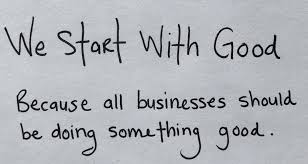

The art with G
se all businesses
ning something g


<start of description>
The image displays a snippet of text written in cursive handwriting on a white, slightly textured background. The text appears to be part of a larger passage, but only a portion is visible here. It includes characters which seem to be from an unfamiliar script, possibly from a language that uses letters resembling modern English but not the common ones. These could be characters found in languages like Armenian, though this is speculative without more context. The handwriting style is casual, with varying pressure giving the letters varying sharpness. No additional objects or


'The art with G\nse all businesses\nning something g\n\n\n<start of description>\nThe image displays a snippet of text written in cursive handwriting on a white, slightly textured background. The text appears to be part of a larger passage, but only a portion is visible here. It includes characters which seem to be from an unfamiliar script, possibly from a language that uses letters resembling modern English but not the common ones. These could be characters found in languages like Armenian, though this is speculative without more context. The handwriting style is casual, with varying pressure giving the letters varying sharpness. No additional objects or'

In [2]:
analyse("./image.png")